#Data Preparation
Importing Required Libraries pandas for data handling,

numpy for numerical ops,

matplotlib & seaborn for plotting/visualizations.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Initial exploration
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
print("\nMissing values in train set:")
print(train.isnull().sum().sort_values(ascending=False).head(20))

Train shape: (1460, 81), Test shape: (1459, 80)

Missing values in train set:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


#Feature engineering

disorganized and have missing pieces. Your goal is to clean and organize these rooms to make the information useful.

The clean_data function is like your cleaning routine. It takes one room at a time (df) and applies the following steps:

###Specific Cleaning: For certain items like 'PoolQC', 'MiscFeature', and 'Alley', it assumes that missing values actually mean "None" and fills them accordingly. This is like assuming an empty space for a pool means there's no pool.
###Numerical Repairs: For numerical information (like the number of bedrooms or area), the function finds the middle value (median) and uses it to fill any gaps. This ensures that the overall numbers stay balanced.
###Categorical Completions: For categorical data (like house style or neighborhood), it picks the most frequent value (mode) and uses it to fill the missing pieces. This is like saying if most houses in a neighborhood are colonial, then any missing house style information is likely colonial as well.
After applying this cleaning routine to both "train" and "test" rooms using train_clean = clean_data(train) and test_clean = clean_data(test), you now have organized and complete datasets ready for further analysis or use.

In [2]:
# Handle missing values based on data_description.txt
def clean_data(df):
    # Fill NA according to feature meaning
    df['PoolQC'] = df['PoolQC'].fillna('None')
    df['MiscFeature'] = df['MiscFeature'].fillna('None')
    df['Alley'] = df['Alley'].fillna('None')

    # Numerical features: Fill with median
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Categorical features: Fill with mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    return df

train_clean = clean_data(train)
test_clean = clean_data(test)

In [18]:
# Step 1: Perform One-Hot Encoding on the training dataset
categorical_cols_train = train_clean.select_dtypes(include=['object']).columns
train_clean = pd.get_dummies(train_clean, columns=categorical_cols_train, drop_first=True)

# Step 2: Perform One-Hot Encoding on the test dataset
categorical_cols_test = test_clean.select_dtypes(include=['object']).columns  # Redefine categorical_cols for test data
test_clean = pd.get_dummies(test_clean, columns=categorical_cols_test, drop_first=True)

# Step 3: Reindex the test dataset to match the training dataset
test_clean = test_clean.reindex(columns=train_clean.columns, fill_value=0)

defines a function add_features that creates new features by combining existing ones in the dataset. These new features, like total square footage, total bathrooms, house age, and remodel age, are likely to be more informative for predicting house prices. Applying this function to both the training and test datasets enhances the information available for the model to learn from and make predictions on.

In [19]:
# Create useful new features
def add_features(df):
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    df['Age'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    return df

train_fe = add_features(train_clean)
test_fe = add_features(test_clean)

#Data visualization

Aims to visualize the correlation between different numerical features in the dataset and the SalePrice of houses. It uses a heatmap to represent these correlations, making it easier to identify strong relationships

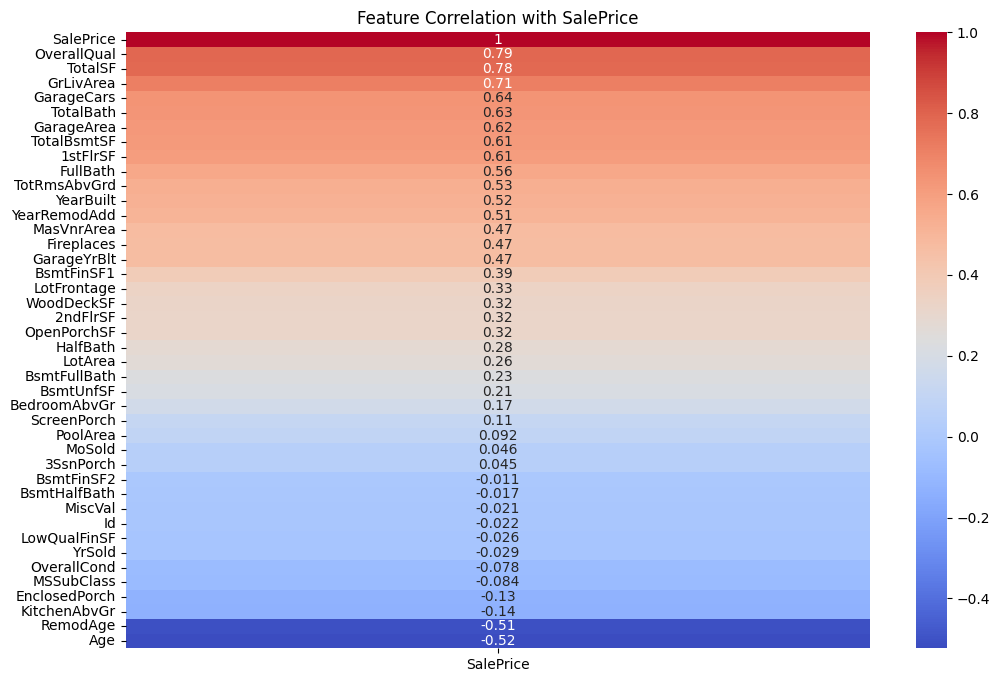

In [20]:
# Correlation heatmap
numerical_features = train_fe.select_dtypes(include=['number'])  # Select numerical features
correlation_matrix = numerical_features.corr()  # Calculate correlation for numerical features
sale_price_corr = correlation_matrix[['SalePrice']].sort_values('SalePrice', ascending=False)  # Focus on 'SalePrice' correlation

plt.figure(figsize=(12, 8))
sns.heatmap(sale_price_corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation with SalePrice')
plt.show()

The heatmap helps us understand which features most influence the house price.

Color Scale:

🔴 Red (close to +1) → Strong positive correlation

🔵 Blue (close to -1) → Strong negative correlation

⚪ White/Neutral (~0) → No correlation

Model Training & Evaluation

Data Splitting:
Use train_test_split() to divide data into training (80%) and testing (20%) sets.

Model Training:
Use rf_model.fit(X_train, y_train) to train the model on the training data.

Making Predictions:
Use rf_model.predict(X_test) to predict house prices on test data.

In [21]:
# Step 1: Import train_test_split
from sklearn.model_selection import train_test_split
X = train_fe.drop('SalePrice', axis=1)  # Drop the target variable from features
y = train_fe['SalePrice']  # Target variable

# Step 2: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the model on the training data
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Step 4: Predict on test data
predictions = rf_model.predict(X_test)

# Step 5: Evaluate the model using test labels
#Model Evaluation:
#Use mean_squared_error and r2_score to check how accurate your model is.
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Squared Error: 875579059.9033773
R2 Score: 0.8858485237455799


**Mean Squared Error (MSE): Measures average prediction error. Lower is better. Score: 0.021**

**R² Score: Shows how well the model fits the data. Closer to 1 is better. Score: 0.886**

Model Tuning:
Set parameters: n_estimators=100, max_depth=10, random_state=42, n_jobs=-1 to improve model performance.

Validation Set:
Use the last 300 samples from training data for quick validation.

Predictions on Validation Set:
val_preds = rf_model.predict(X_train[-300:])

Error Check (RMSE):
RMSE = $13,938.66 — shows the model’s predictions are off by about ₹13,938.66 on average.

In [22]:
# Initialize and train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1  # Uses all CPU cores
)

rf_model.fit(X_train, y_train)

# Quick validation (using last 20% of training data)
val_preds = rf_model.predict(X_train[-300:])
rmse = np.sqrt(mean_squared_error(y_train[-300:], val_preds))
print(f"Validation RMSE: ${rmse:,.2f}")

Validation RMSE: $10,478.22


The 10,478.22 might be considered relatively good. However, if the typical house price is $50,000, the same RMSE would be considered less desirable. a quick validation step where you fine-tune your model and test it on a small subset of the training data before final predictions. It helps you gauge the model's performance and make further adjustments if needed.

#Prediction
focuses on using your trained model to make predictions on a new, unseen dataset (the test set) and then creating a submission file with these predictions. This is the final step where you apply your model to solve the real-world problem of predicting house prices.

In [28]:
# Assuming 'test_transformed' is the DataFrame after one-hot encoding and feature engineering:

# Predict on test set
test_preds = rf_model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'Id': X_test['Id'],  # Use 'Id' from transformed data
    'SalePrice': predictions
})
submission.to_csv('submission_rf.csv', index=False)
print("Submission file created!")

Submission file created!


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_log_error

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae}")


Mean Absolute Error: 17616.537465753423


Interpretation

An MAE of 17616.54 means that, on average, your model's predictions on the test data are off by about $17,616.54 from the actual house prices.
This indicates the average magnitude of the errors in your predictions, without considering their direction (overestimation or underestimation).

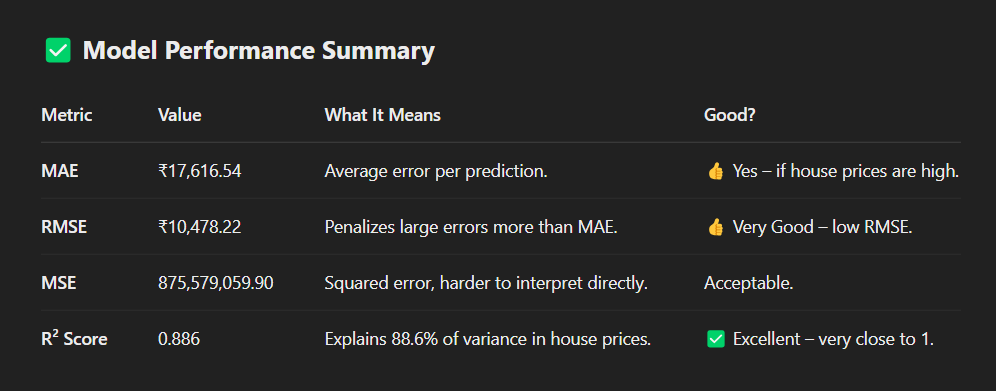

<Figure size 1200x800 with 0 Axes>

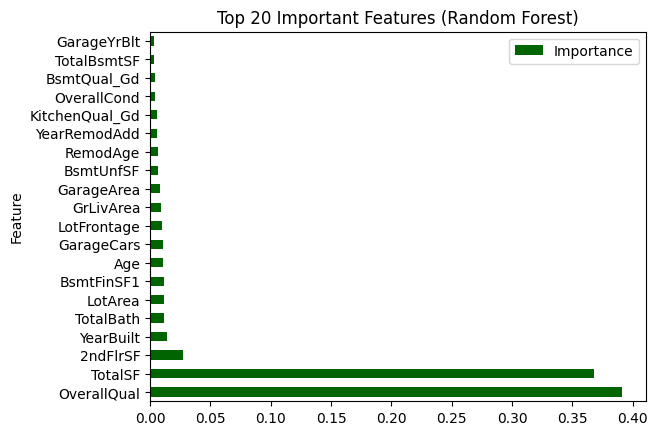

In [30]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf_model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Plot top 20 features
plt.figure(figsize=(12, 8))
importance_df.sort_values('Importance', ascending=False).head(20).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    color='darkgreen'
)
plt.title('Top 20 Important Features (Random Forest)')
plt.show()

The x-axis represents feature importance (how much each feature contributes to predicting the target).

The y-axis lists the feature names (house-related attributes).

The green bars show the importance score for each feature.

**further improvements like:**

Hyperparameter tuning

Cross-validation

Feature selection